# YOLO_v8s Custom Dataset (3 Classes)

* https://github.com/ultralytics/ultralytics

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# I. Custom Data_Set

* 3 Classes

>## 1) wget From Github

* 'maskdataset_3C.tar' 파일 다운로드

In [1]:
!wget https://raw.githubusercontent.com/rusita-ai/pyData/master/maskdataset_3C.tara{a,b,c,d,e}

--2026-08-25 00:58:34--  https://raw.githubusercontent.com/rusita-ai/pyData/master/maskdataset_3C.taraa
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 94371840 (90M) [application/octet-stream]
Saving to: ‘maskdataset_3C.taraa’

maskdataset_3C.tara 100%[===================>]  90.00M   214MB/s    in 0.4s    

2026-08-25 00:58:37 (214 MB/s) - ‘maskdataset_3C.taraa’ saved [94371840/94371840]

--2026-08-25 00:58:37--  https://raw.githubusercontent.com/rusita-ai/pyData/master/maskdataset_3C.tarab
Reusing existing connection to raw.githubusercontent.com:443.
HTTP request sent, awaiting response... 200 OK
Length: 94371840 (90M) [application/octet-stream]
Saving to: ‘maskdataset_3C.tarab’

maskdataset_3C.tara 100%[===================>]  90.00M   179MB/s    in 0.5s  

* 현재 작업 경로

In [2]:
%pwd

'/content'

* 다운로드 결과 확인

In [3]:
!ls -l

total 408144
-rw-r--r-- 1 root root 94371840 Aug 25 00:58 maskdataset_3C.taraa
-rw-r--r-- 1 root root 94371840 Aug 25 00:58 maskdataset_3C.tarab
-rw-r--r-- 1 root root 94371840 Aug 25 00:58 maskdataset_3C.tarac
-rw-r--r-- 1 root root 94371840 Aug 25 00:58 maskdataset_3C.tarad
-rw-r--r-- 1 root root 40448000 Aug 25 00:58 maskdataset_3C.tarae
drwxr-xr-x 1 root root     4096 Aug 20 13:35 sample_data


>## 2) Unzip

In [ ]:
!cat maskdataset_3C.tar* | tar xf -

* 실행 결과 확인
 - 'yolo_custom_modeling' 디렉토리 생성

In [ ]:
!ls -l

total 408148
-rw-r--r-- 1 root root 94371840 May  2 04:49 maskdataset_3C.taraa
-rw-r--r-- 1 root root 94371840 May  2 04:49 maskdataset_3C.tarab
-rw-r--r-- 1 root root 94371840 May  2 04:49 maskdataset_3C.tarac
-rw-r--r-- 1 root root 94371840 May  2 04:49 maskdataset_3C.tarad
-rw-r--r-- 1 root root 40448000 May  2 04:49 maskdataset_3C.tarae
drwxr-xr-x 1 root root     4096 Apr 30 13:37 sample_data
drwxr-xr-x 3 root root     4096 Feb  2  2023 yolo_custom_modeling


# II. Train vs. Test Split

* 현재 작업 경로

In [ ]:
!pwd

/content


>## 1) Image Files

In [ ]:
from glob import glob

img_list = glob('/content/yolo_custom_modeling/dataset/images/*.png')

print(len(img_list))

843


>## 2) Label Files

In [ ]:
from glob import glob

txt_list = glob('/content/yolo_custom_modeling/dataset/labels/*.txt')

print(len(txt_list))

843


>## 3) train_test_split( )

* 8:2

In [ ]:
from sklearn.model_selection import train_test_split

train_img_list, valid_img_list = train_test_split(img_list,
                                                test_size = 0.2,
                                                random_state = 2045)

print(len(train_img_list), len(valid_img_list))

674 169


* 목록 확인

In [ ]:
print('Train_Img: ', train_img_list)
print('Valid_Img: ', valid_img_list)

Train_Img:  ['/content/yolo_custom_modeling/dataset/images/maksssksksss28.png', '/content/yolo_custom_modeling/dataset/images/maksssksksss724.png', '/content/yolo_custom_modeling/dataset/images/maksssksksss824.png', '/content/yolo_custom_modeling/dataset/images/maksssksksss119.png', '/content/yolo_custom_modeling/dataset/images/maksssksksss511.png', '/content/yolo_custom_modeling/dataset/images/maksssksksss580.png', '/content/yolo_custom_modeling/dataset/images/maksssksksss361.png', '/content/yolo_custom_modeling/dataset/images/maksssksksss21.png', '/content/yolo_custom_modeling/dataset/images/maksssksksss235.png', '/content/yolo_custom_modeling/dataset/images/maksssksksss81.png', '/content/yolo_custom_modeling/dataset/images/maksssksksss654.png', '/content/yolo_custom_modeling/dataset/images/maksssksksss357.png', '/content/yolo_custom_modeling/dataset/images/maksssksksss276.png', '/content/yolo_custom_modeling/dataset/images/maksssksksss350.png', '/content/yolo_custom_modeling/dataset

>## 4) Train.txt & Valid.txt 생성

In [ ]:
with open('/content/yolo_custom_modeling/dataset/Train.txt', 'w') as f:
  f.write('\n'.join(train_img_list) + '\n')

with open('/content/yolo_custom_modeling/dataset/Valid.txt', 'w') as f:
  f.write('\n'.join(valid_img_list) + '\n')

* 생성 확인

In [ ]:
!ls -l /content/yolo_custom_modeling/dataset/*.txt

-rw-r--r-- 1 root root 43722 May  2 04:49 /content/yolo_custom_modeling/dataset/Train.txt
-rw-r--r-- 1 root root 10963 May  2 04:49 /content/yolo_custom_modeling/dataset/Valid.txt


>## 5) data.yaml 생성

In [ ]:
yaml_text = """train: /content/yolo_custom_modeling/dataset/Train.txt
val: /content/yolo_custom_modeling/dataset/Valid.txt

nc: 3
names: ['mask', 'w_mask', 'no_mask']"""

with open('/content/yolo_custom_modeling/dataset/data.yaml', 'w') as file:
    file.write(yaml_text)

* 생성 확인

In [ ]:
%cat /content/yolo_custom_modeling/dataset/data.yaml

train: /content/yolo_custom_modeling/dataset/Train.txt
val: /content/yolo_custom_modeling/dataset/Valid.txt

nc: 3
names: ['mask', 'w_mask', 'no_mask']

# III. Install YOLO_v8

https://github.com/ultralytics/ultralytics

In [ ]:
!pip install -q ultralytics

import ultralytics
ultralytics.checks()

Ultralytics 8.3.123 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.9/112.6 GB disk)


# IV. Model Learning

>## 1) YOLO_v8s

* yolov8s.pt
 - 약 20분

* https://docs.ultralytics.com/usage/cfg/

In [ ]:
%%time

!yolo task = detect \
      mode = train \
      model = yolov8s.pt \
      data = /content/yolo_custom_modeling/dataset/data.yaml \
      epochs = 25 \
      imgsz = 640 \
      plots = True

100% 21.5M/21.5M [00:00<00:00, 159MB/s]
Ultralytics 8.3.123 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/yolo_custom_modeling/dataset/data.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, s

> ## 2) Object Detection 결과 확인

>### (1) Loss & mAP

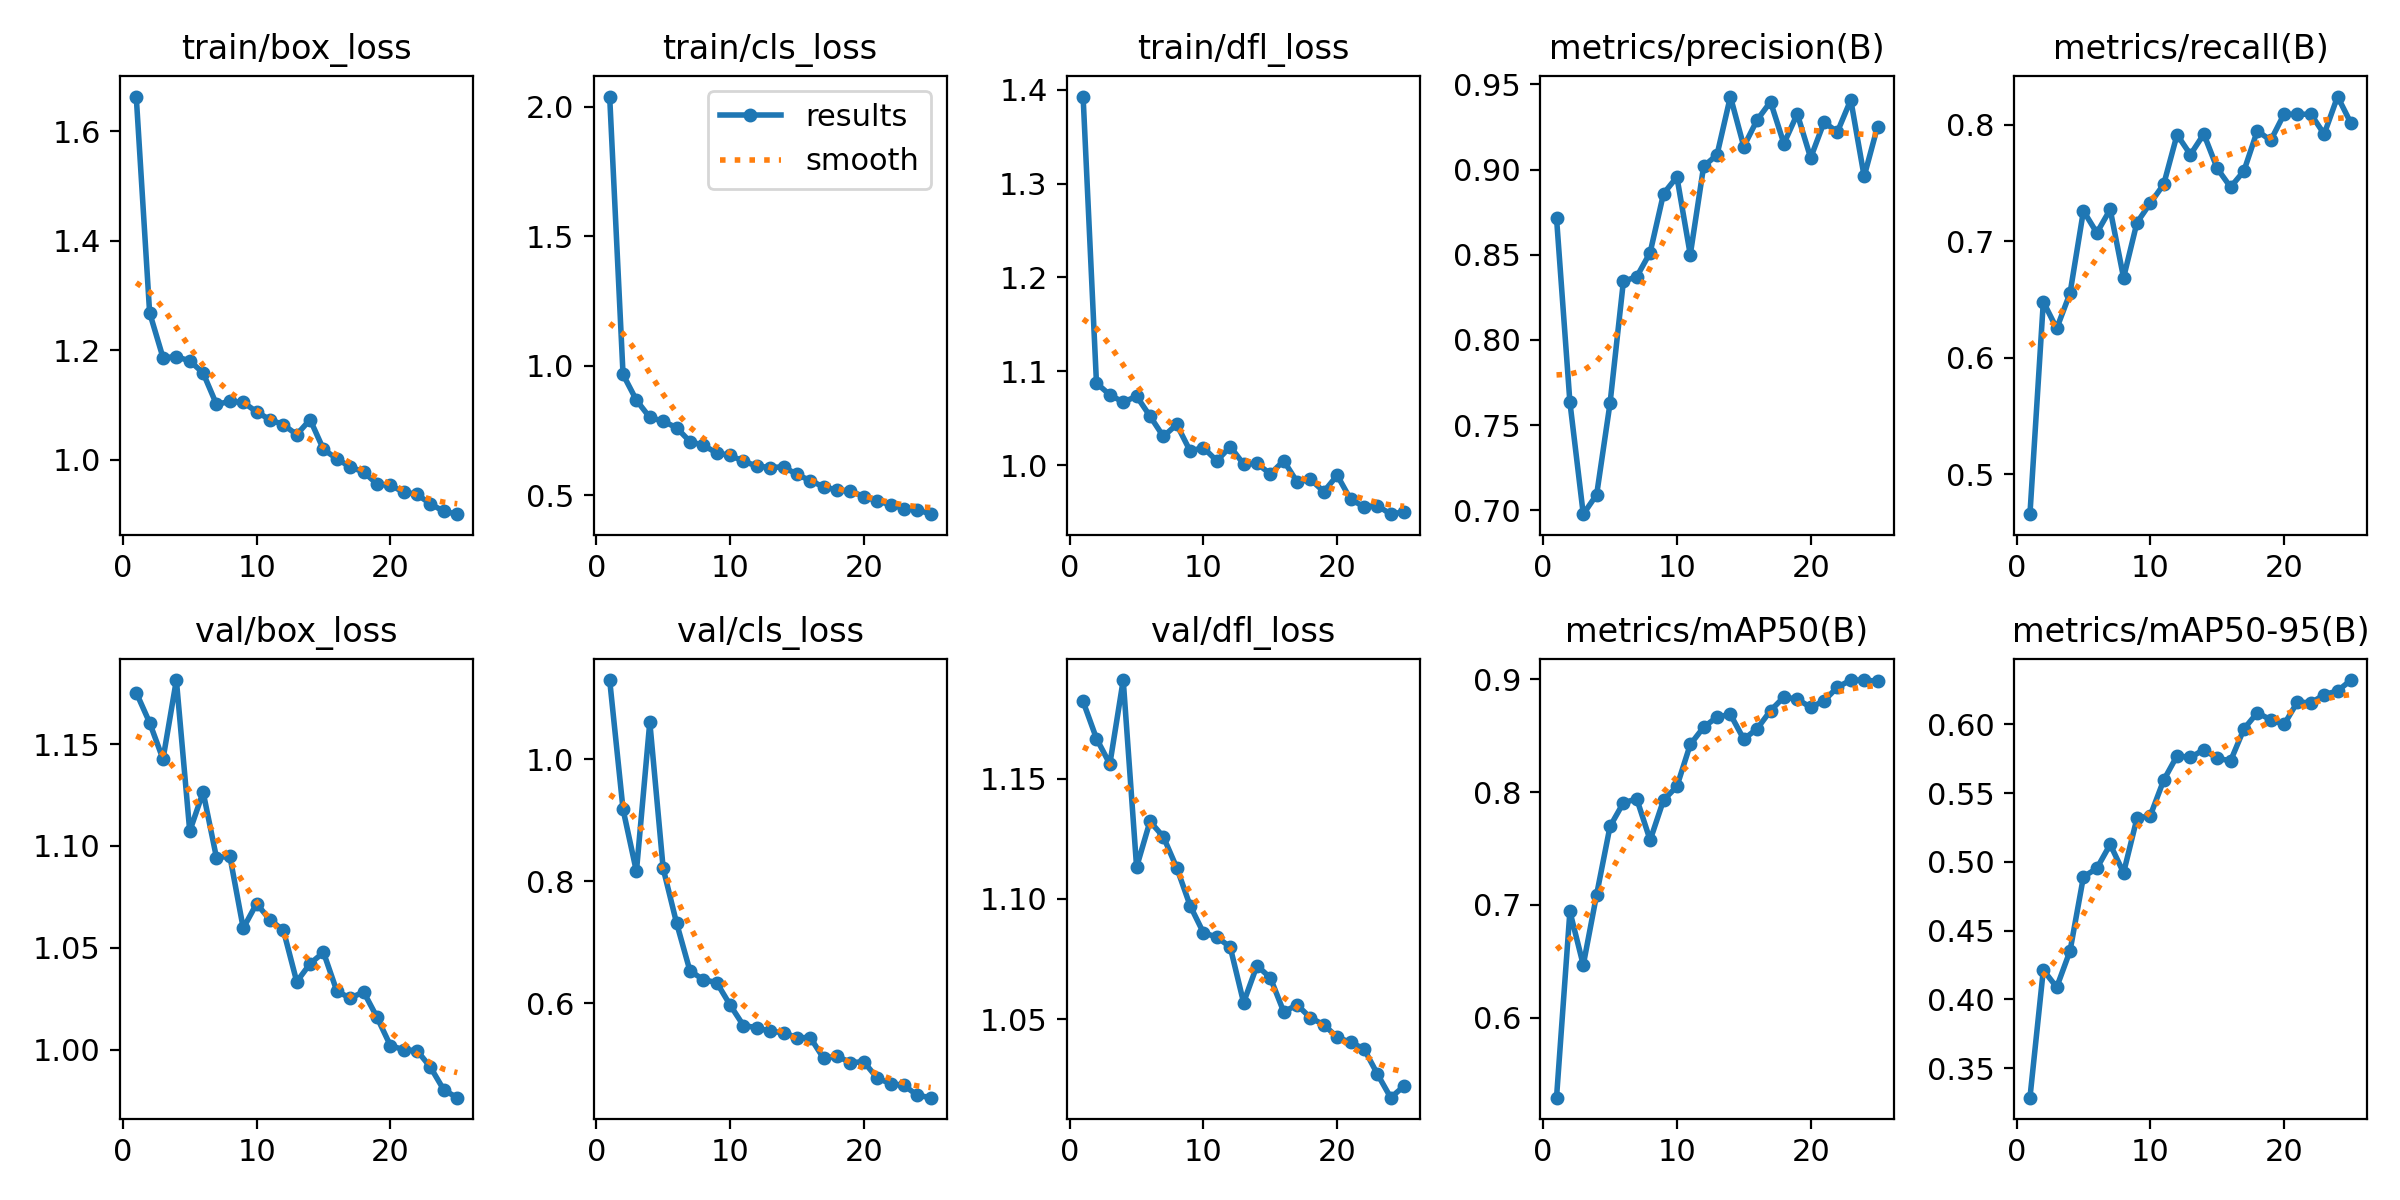

In [ ]:
from IPython.display import Image

Image('/content/runs/detect/train/results.png')

>### (2) Training Results Visualization

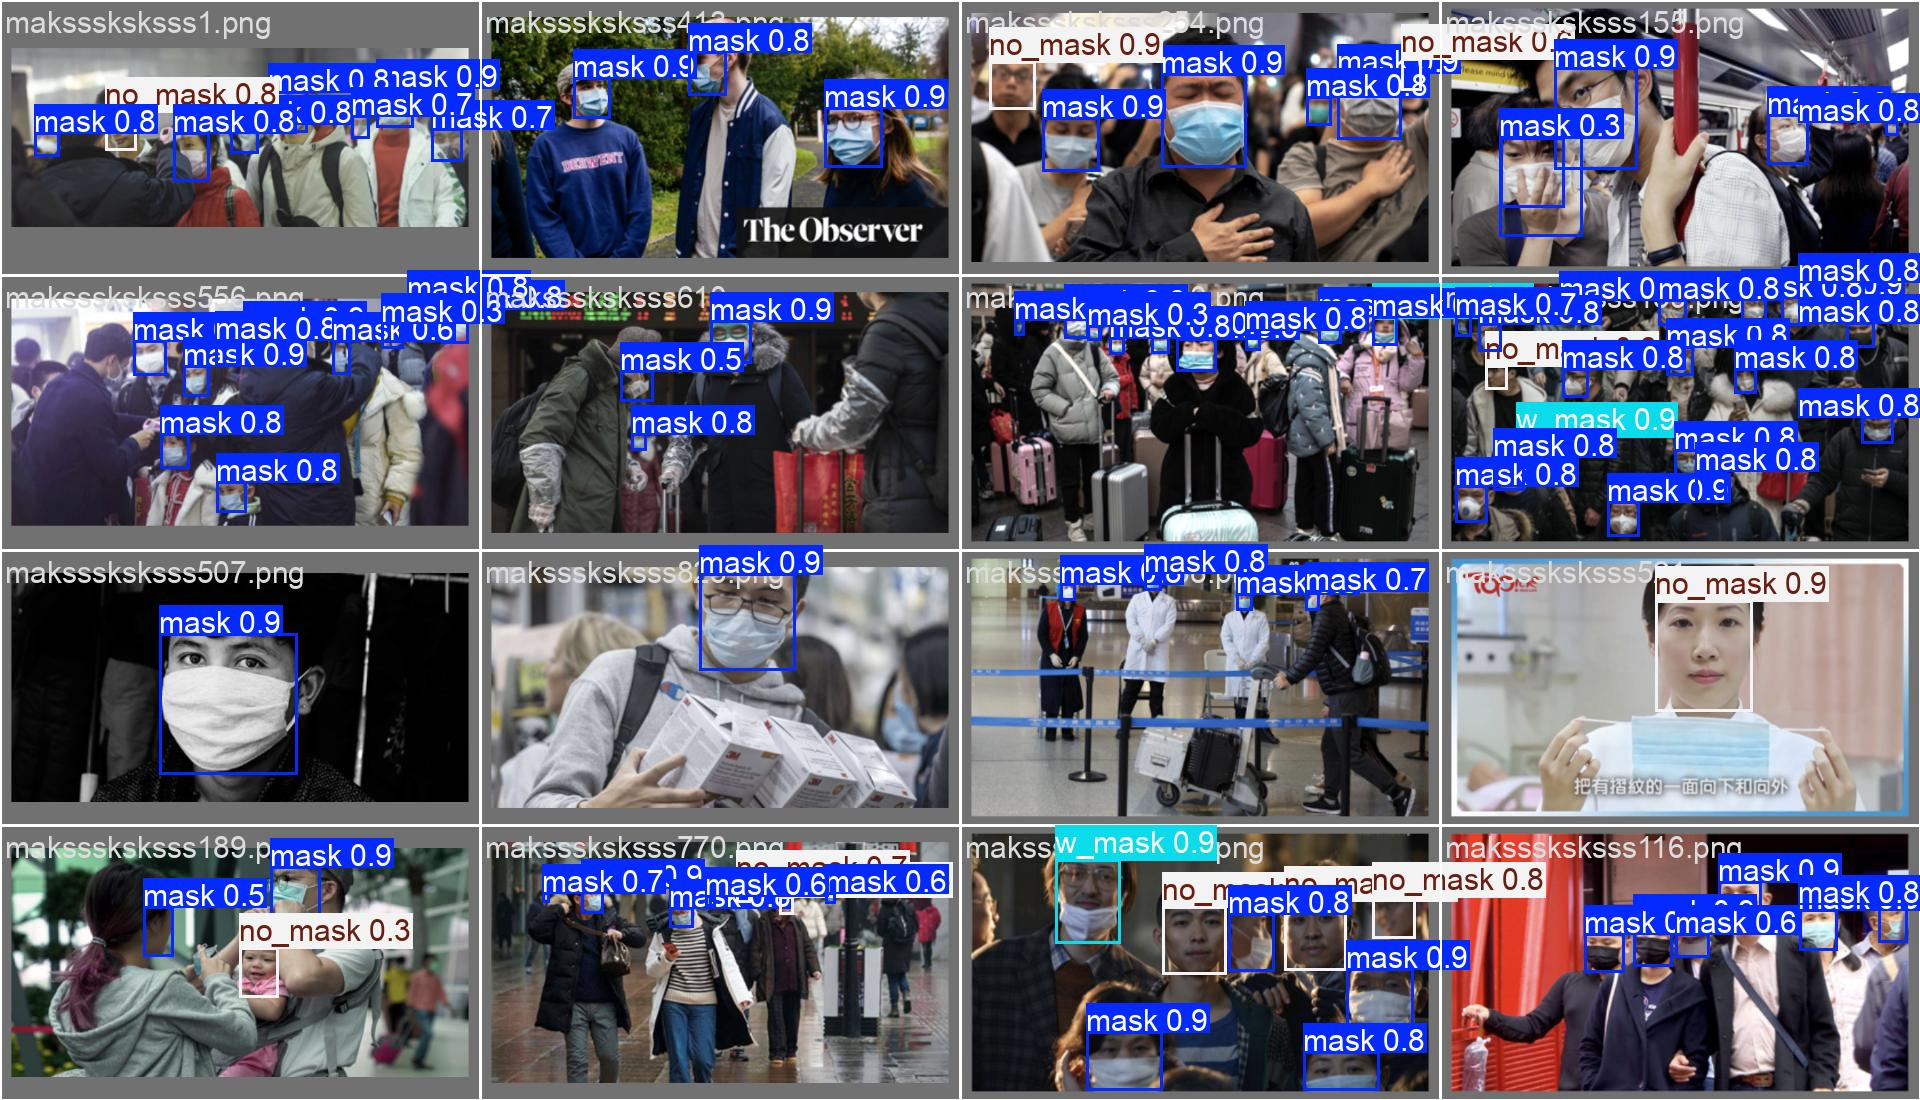

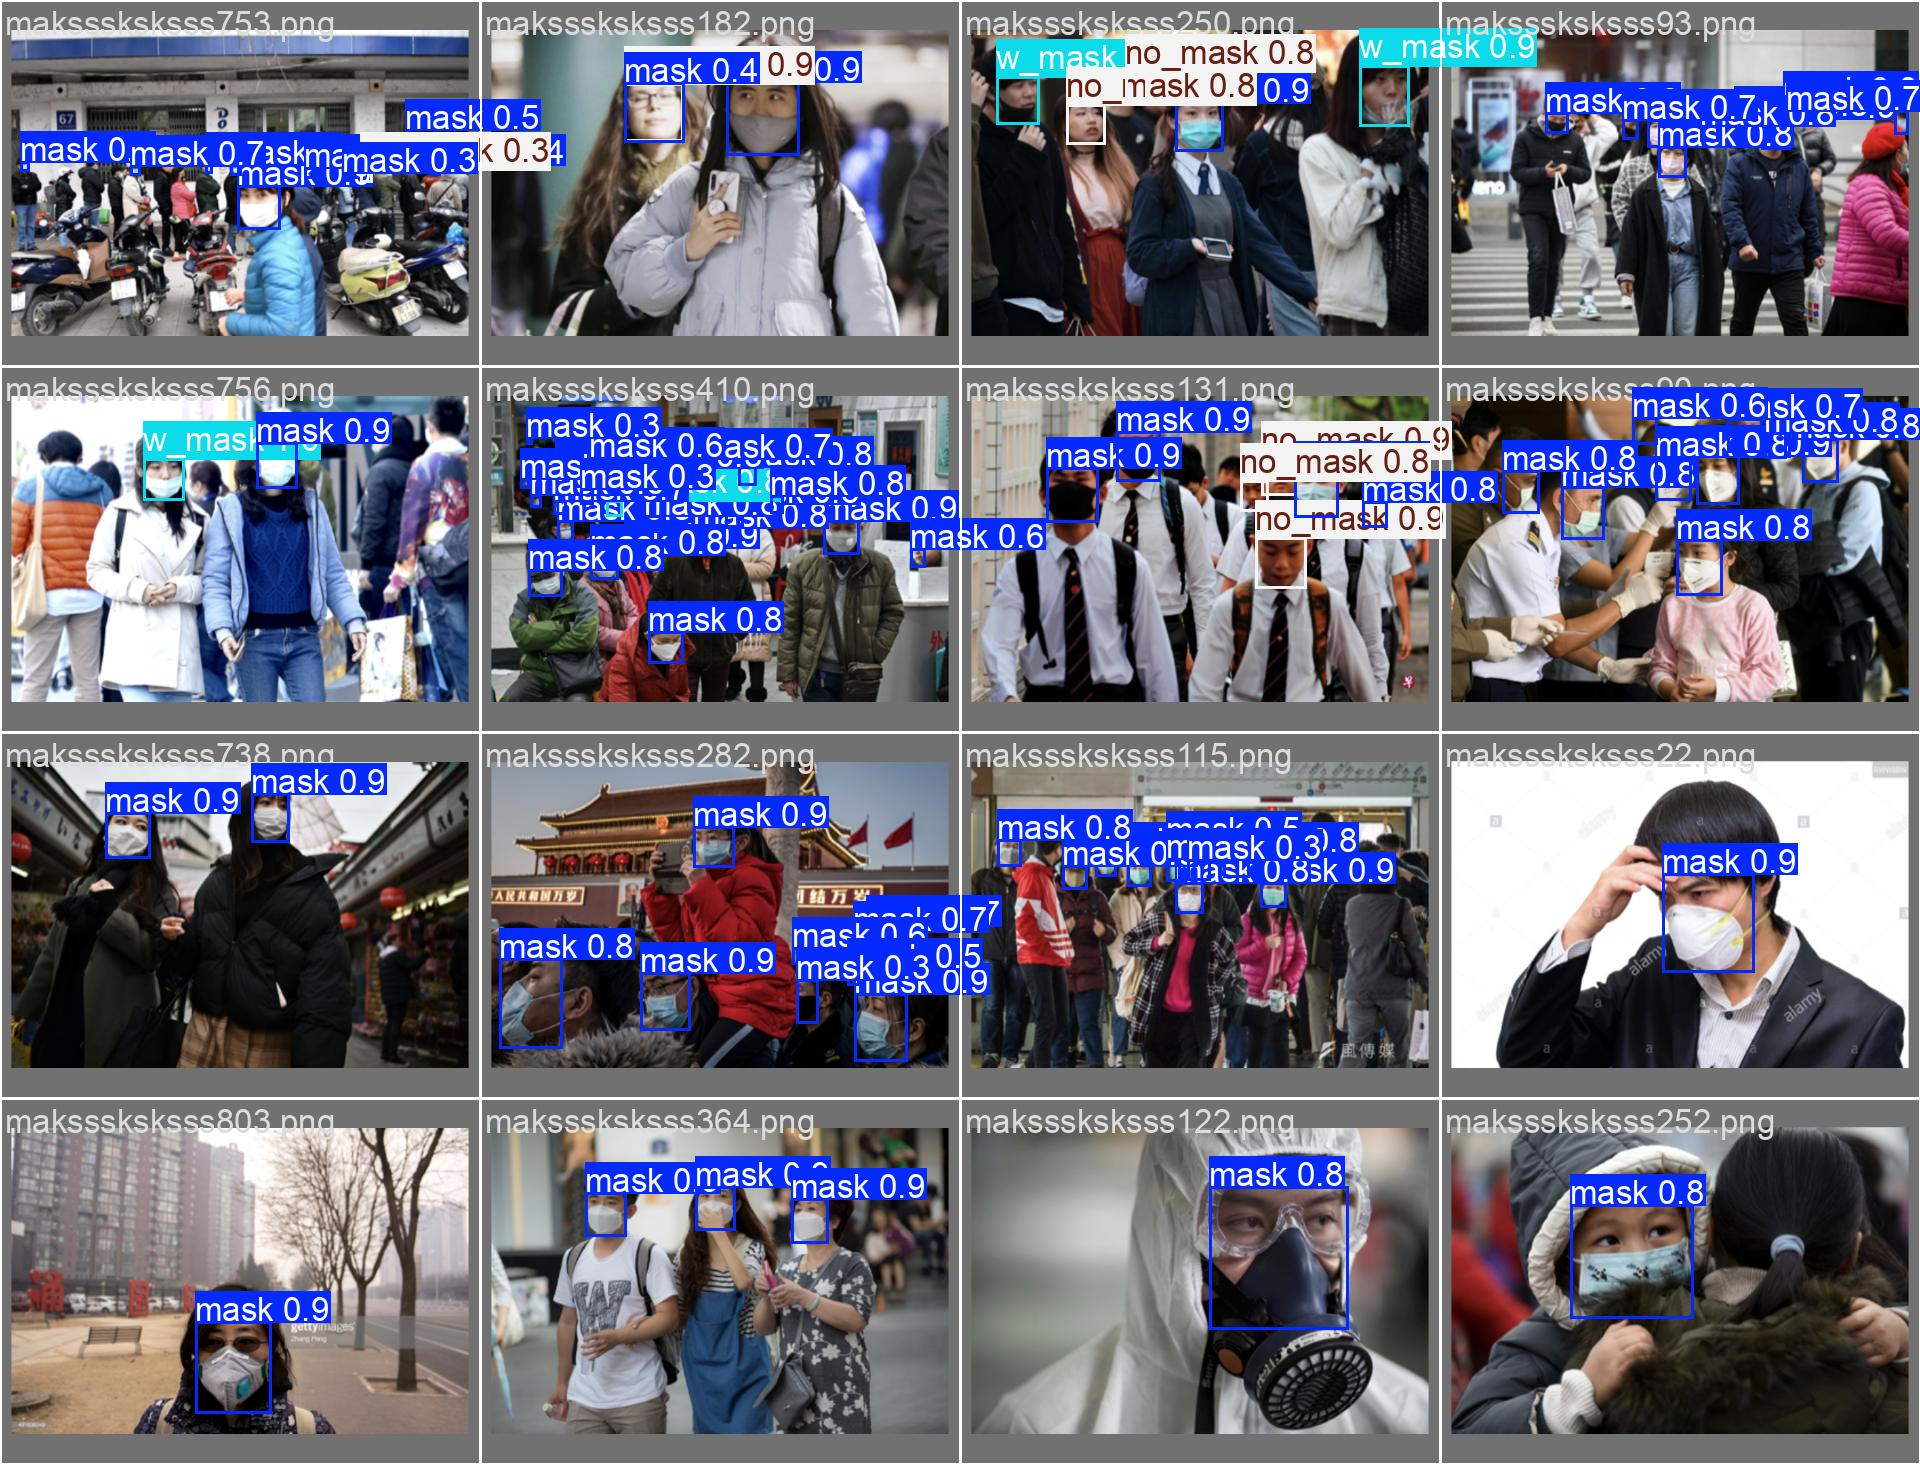

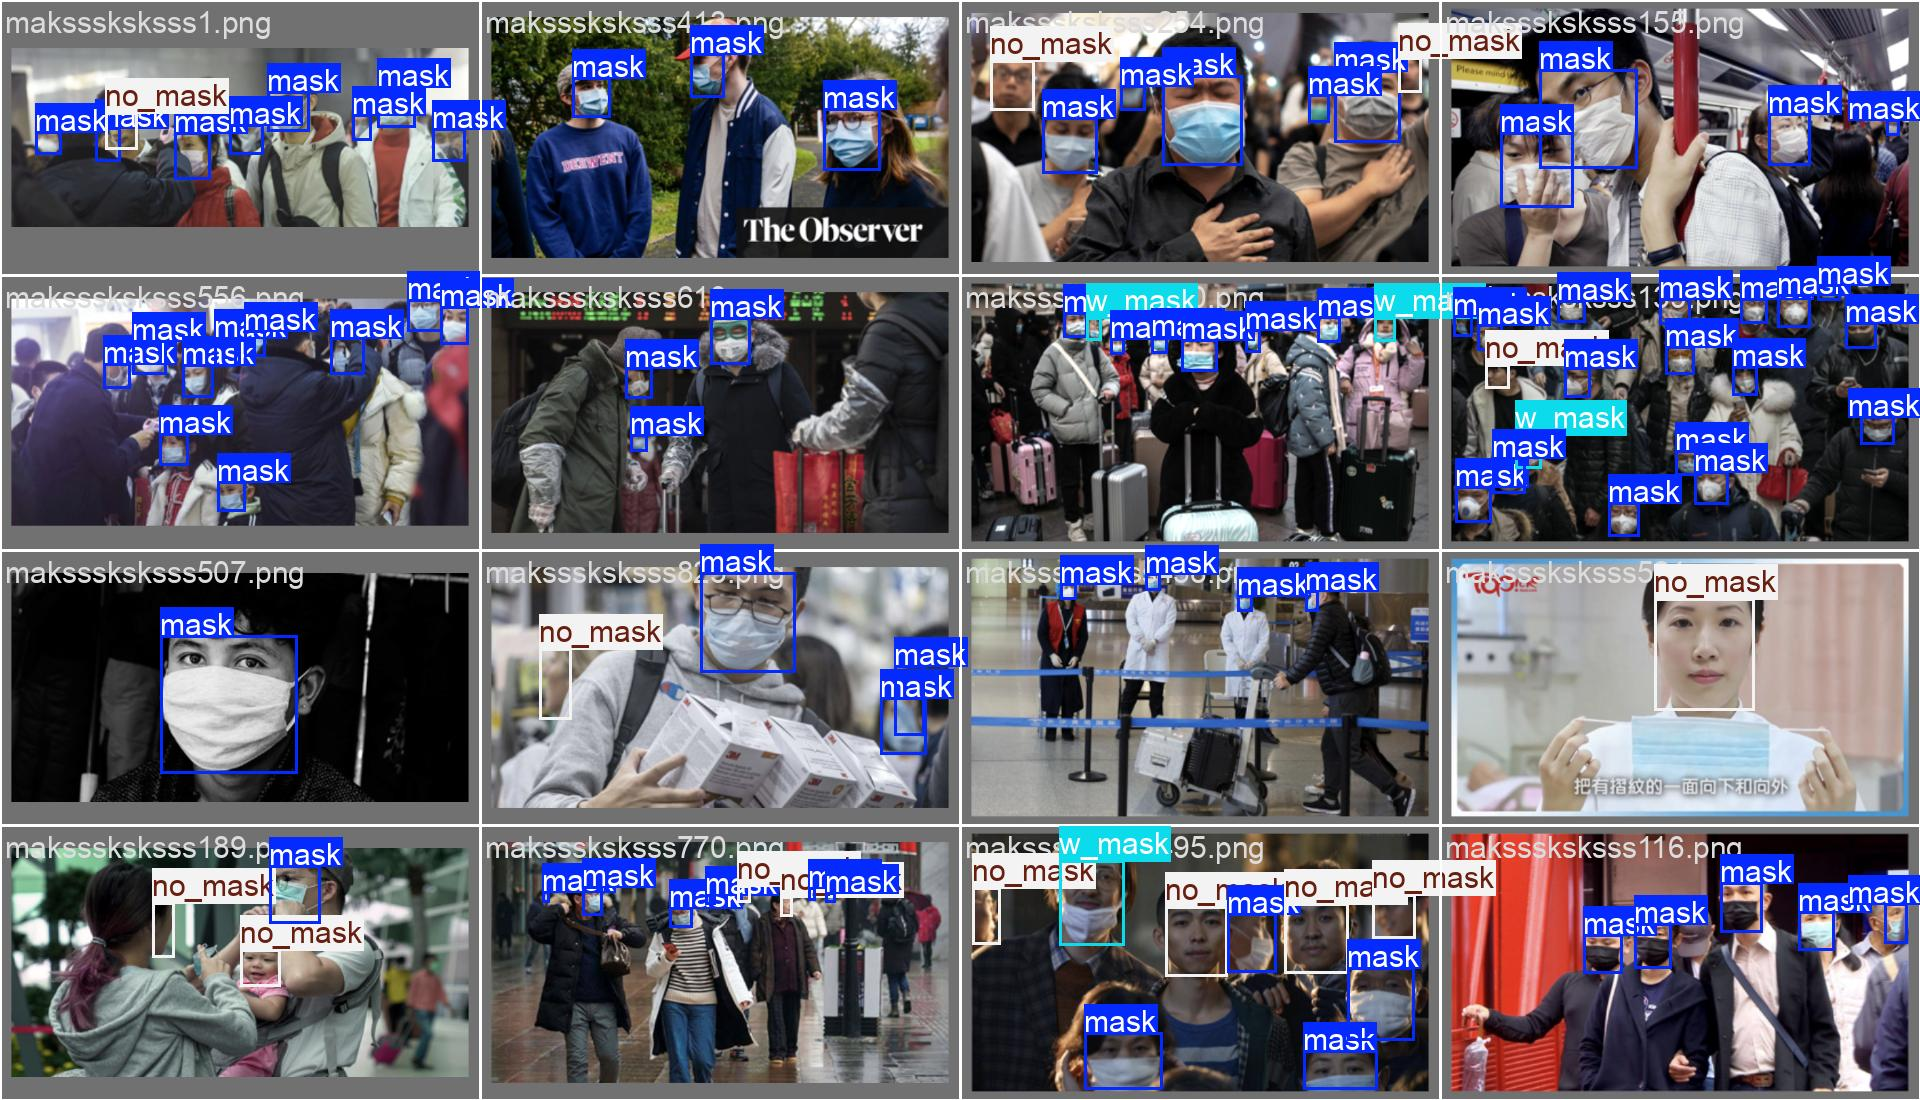

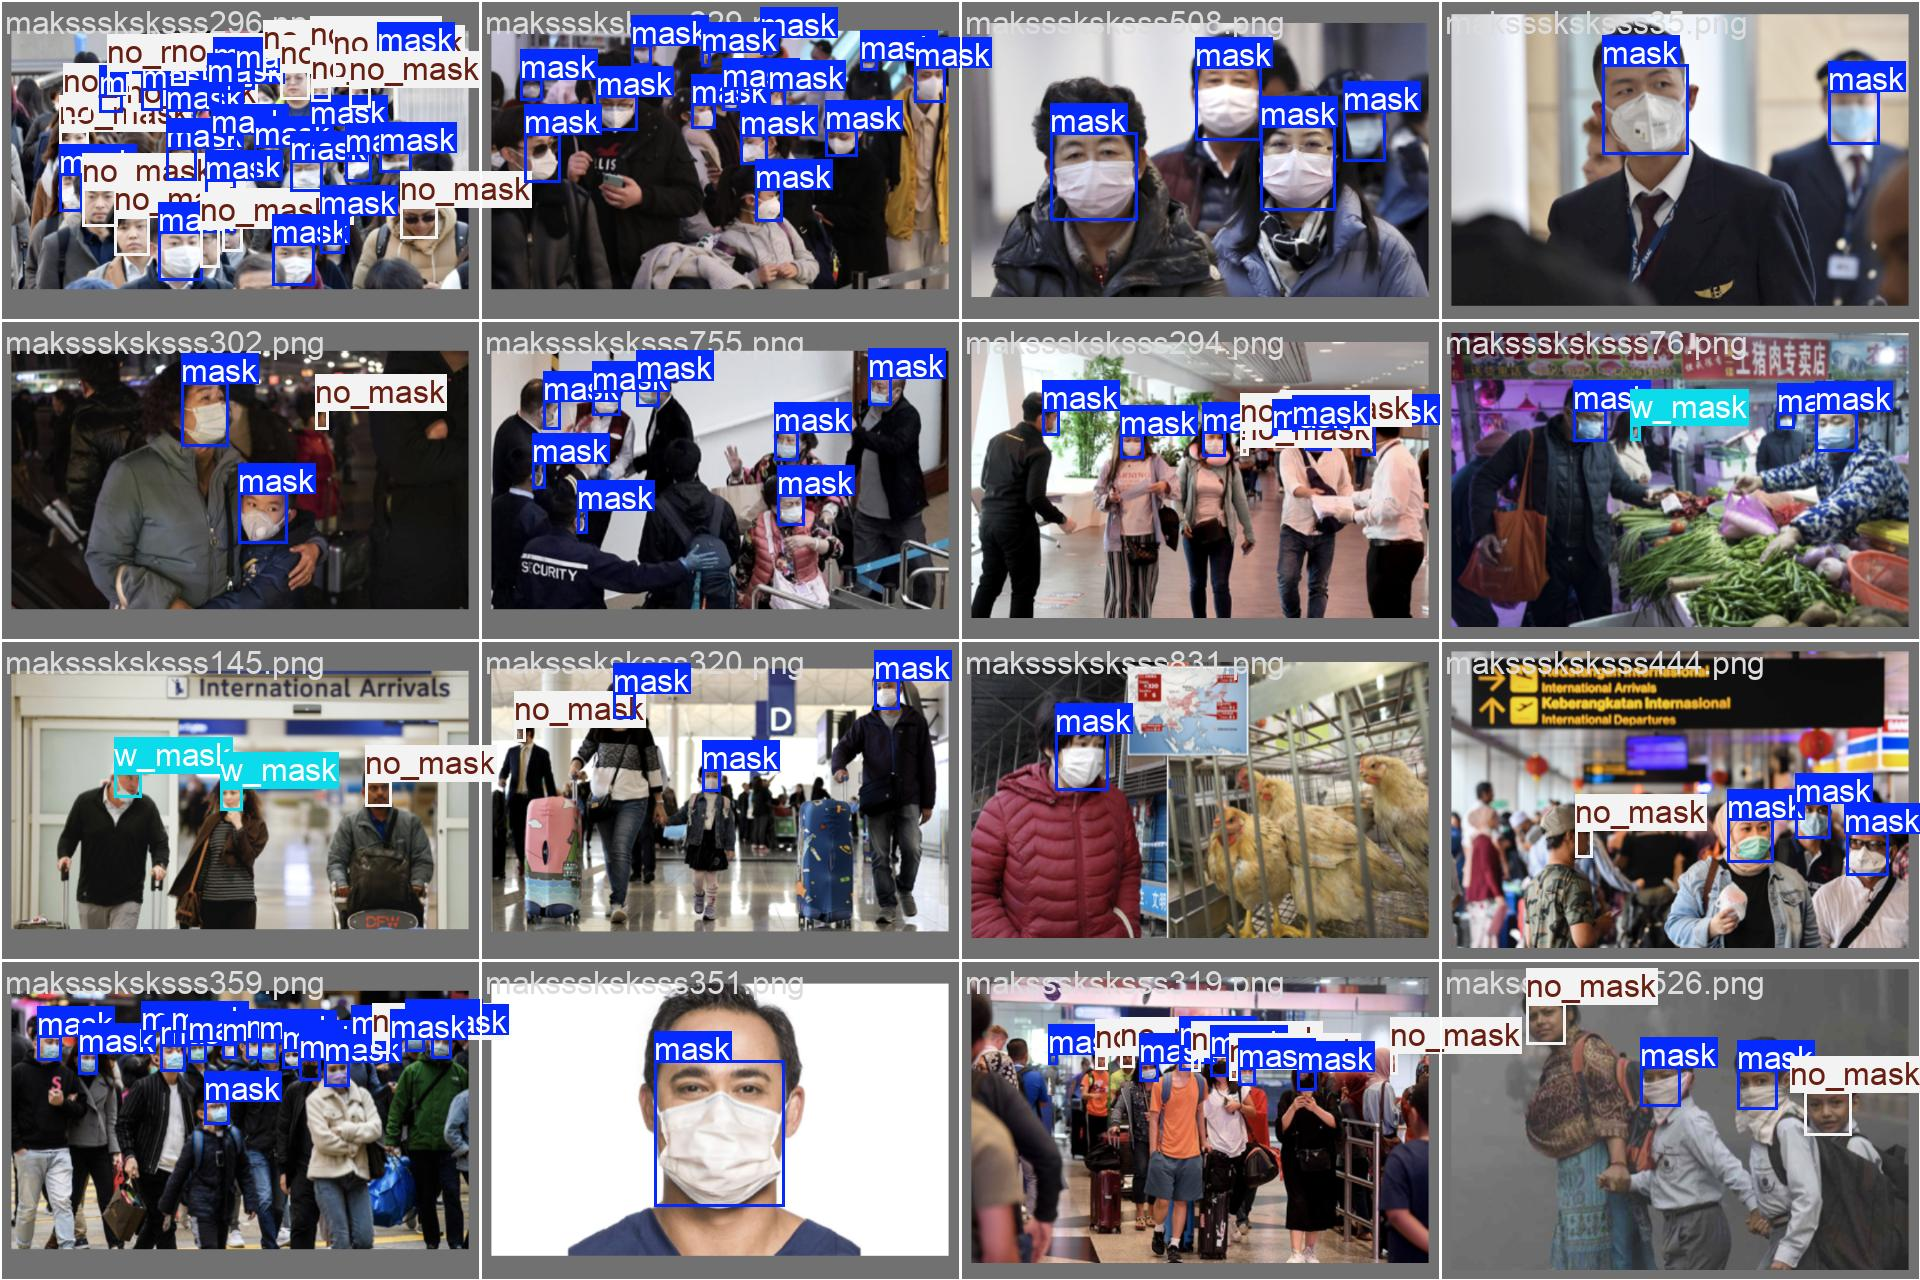

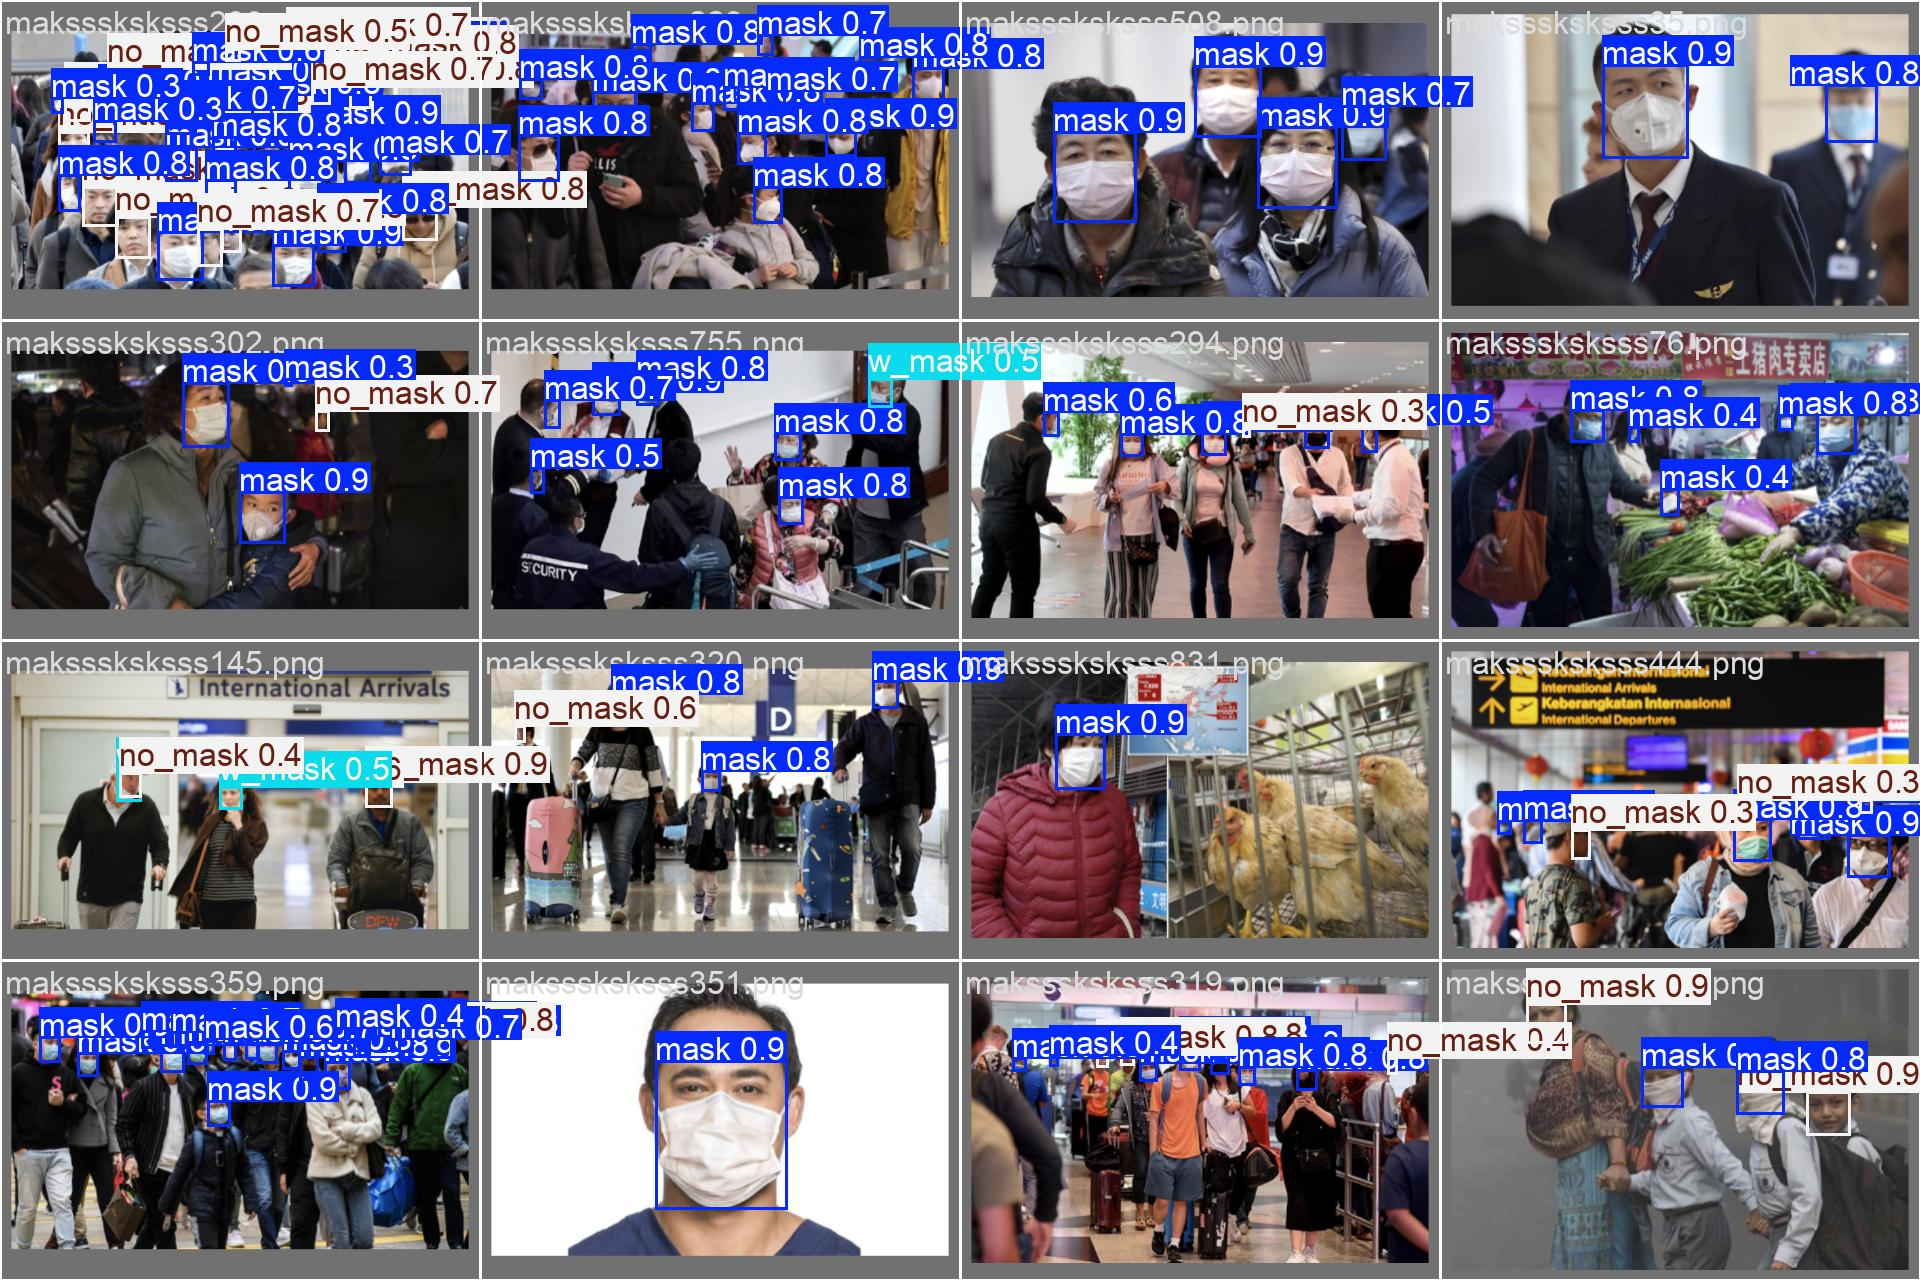

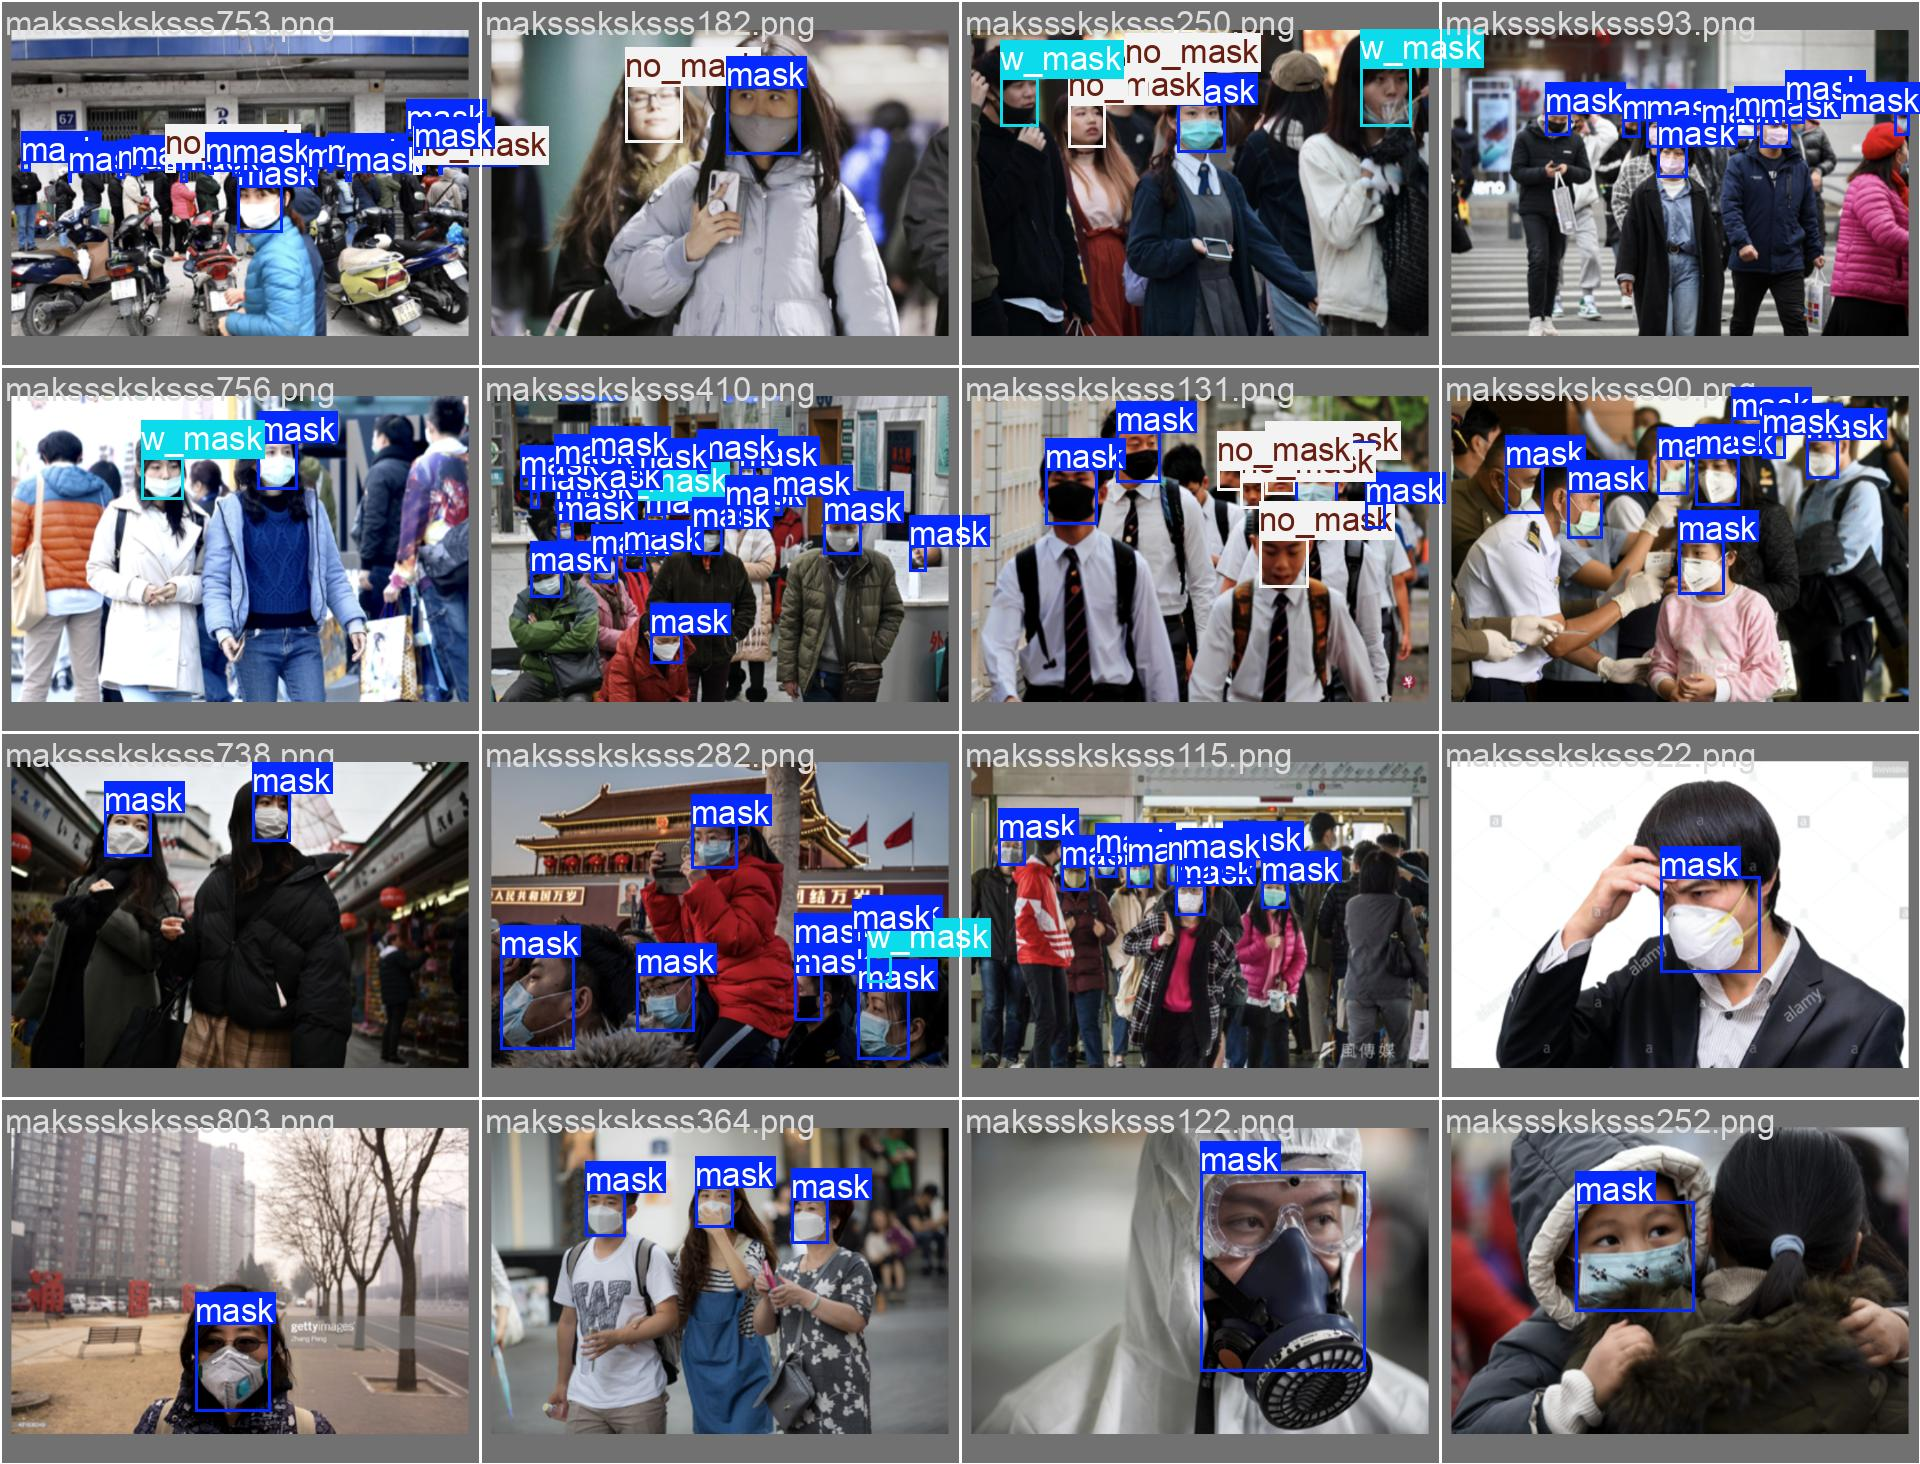

In [ ]:
import glob
from IPython.display import Image, display

for imageName in glob.glob('/content/runs/detect/train/v*.jpg'):
    display(Image(filename=imageName))
    print("\n")

# V. Model Validation

>## 1) Validation 데이터에 best.pt 적용

In [ ]:
!yolo task = detect \
      mode = val \
      model = /content/runs/detect/train/weights/best.pt \
      data = /content/yolo_custom_modeling/dataset/data.yaml

Ultralytics 8.3.123 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3176.5±1848.7 MB/s, size: 568.4 KB)
val: Scanning /content/yolo_custom_modeling/dataset/labels.cache... 169 images, 0 backgrounds, 0 corrupt: 100% 169/169 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 11/11 [00:06<00:00,  1.81it/s]
                   all        169        910      0.925      0.801        0.9      0.627
                  mask        151        739      0.964      0.867      0.954      0.674
                w_mask         21         29      0.879      0.753      0.857      0.581
               no_mask         57        142      0.933      0.784       0.89      0.625
Speed: 4.3ms preprocess, 10.9ms inference, 0.0ms loss, 5.0ms postprocess per image
Results saved to runs/detect/val
💡 Learn more at

# VI. Model Test

>## 1) Test Directory
 * --source /content/yolo_custom_modeling/dataset/test

In [ ]:
!yolo task = detect \
      mode = predict \
      model = /content/runs/detect/train/weights/best.pt \
      conf = 0.25 \
      source = /content/yolo_custom_modeling/dataset/test \
      save = True

Ultralytics 8.3.123 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs

image 1/10 /content/yolo_custom_modeling/dataset/test/mask_test_1.png: 640x640 3 masks, 16.5ms
image 2/10 /content/yolo_custom_modeling/dataset/test/mask_test_10.png: 640x448 1 mask, 1 no_mask, 38.5ms
image 3/10 /content/yolo_custom_modeling/dataset/test/mask_test_2.png: 384x640 2 masks, 36.8ms
image 4/10 /content/yolo_custom_modeling/dataset/test/mask_test_3.png: 640x512 1 mask, 51.9ms
image 5/10 /content/yolo_custom_modeling/dataset/test/mask_test_4.png: 384x640 1 mask, 11.3ms
image 6/10 /content/yolo_custom_modeling/dataset/test/mask_test_5.png: 384x640 18 masks, 1 w_mask, 1 no_mask, 10.7ms
image 7/10 /content/yolo_custom_modeling/dataset/test/mask_test_6.png: 448x640 3 masks, 37.8ms
image 8/10 /content/yolo_custom_modeling/dataset/test/mask_test_7.png: 384x640 4 masks, 11.4ms
image 9/10 /content/yolo_custom_modeling/da

>## 2) Results Visualization

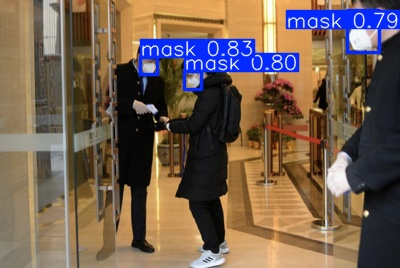

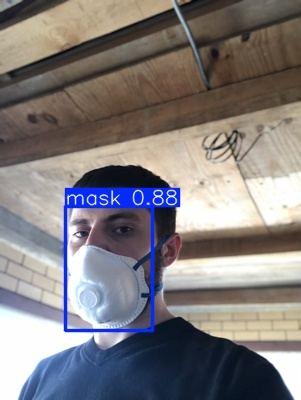

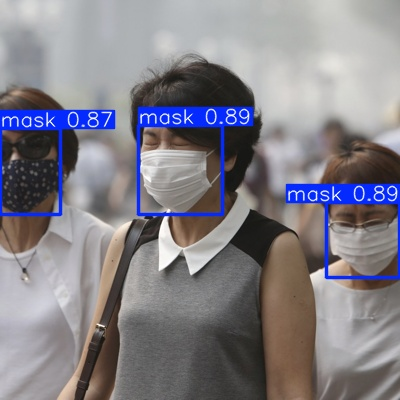

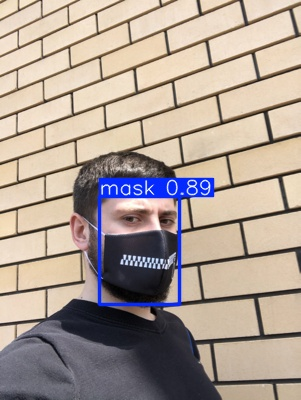

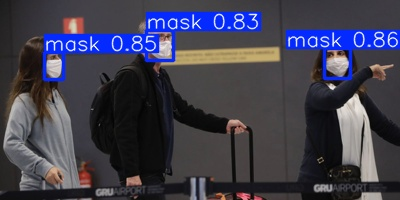

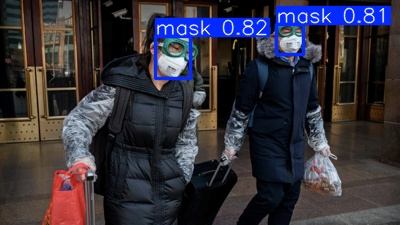

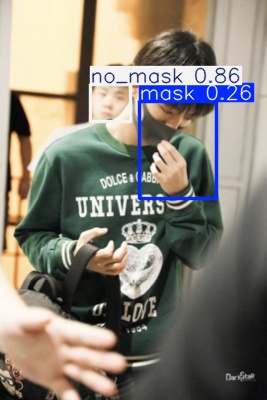

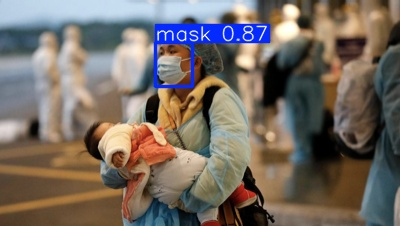

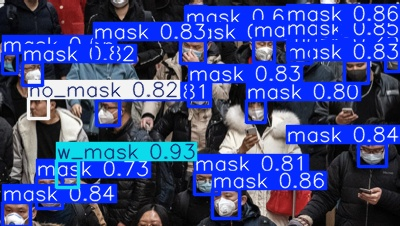

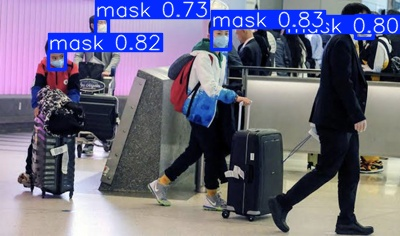

In [ ]:
# display inference on ALL test images

import glob
from IPython.display import Image, display

for imageName in glob.glob('/content/runs/detect/predict/*'): #assuming JPG
    display(Image(filename=imageName))
    print("\n")

#
#
#
# The End
#
#
#